# 📊 Student Performance Analysis using Python, NumPy & Pandas

## Project Overview

This project analyzes student performance using Python, NumPy, Pandas, and Matplotlib.

### Objectives

- Read student data from a CSV file
- Explore and understand the dataset
- Perform statistical analysis
- Create new features (Total, Average, Grade, Status)
- Visualize student performance
- Export the processed dataset

---

## 1. Import Required Libraries

In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Load the Dataset

The student dataset is loaded from a CSV file using Pandas.

In [65]:
# Load the student performance dataset
df = pd.read_csv("../data/student.csv")

## 3. Preview the Dataset

Display the first few rows to understand the structure of the data.

In [66]:
# Display the first five rows of the dataset
df.head()

,Name,Python,SQL,PowerBI
0,Mary,90,85,88
1,John,75,80,70
2,David,95,92,96
3,Priya,88,84,90
4,Rahul,65,72,68


## 4. Explore the Dataset

Examine the dataset's structure, column names, data types, and descriptive statistics.

In [67]:
# Display dataset structure and column information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Name     10 non-null     object
 1   Python   10 non-null     int64 
 2   SQL      10 non-null     int64 
 3   PowerBI  10 non-null     int64 
dtypes: int64(3), object(1)
memory usage: 452.0+ bytes


In [68]:
# Generate descriptive statistics for numerical columns
df.describe()

,Python,SQL,PowerBI
count,10.000000,10.000000,10.000000
mean,83.900000,84.600000,83.900000
std,10.629623,8.058122,10.556199
min,65.000000,72.000000,68.000000
25%,76.750000,79.250000,75.000000
50%,87.500000,84.500000,87.000000
75%,90.750000,91.500000,89.750000
max,96.000000,95.000000,98.000000


In [69]:
# Display the number of rows and columns
df.shape

(10, 4)

In [70]:
# Display column names
df.columns

Index(['Name', 'Python', 'SQL', 'PowerBI'], dtype='object')

## 5. Feature Engineering

Create new columns such as:

- Total Marks
- Average Marks
- Grade
- Status

In [71]:
# Calculate total marks obtained by each student
df["Total"] = df["Python"] + df["SQL"] + df["PowerBI"]

In [72]:
# Calculate the average marks
df["Average"] = df["Total"] / 3

In [73]:
# Assign grades based on average marks
def grade(avg):

    if avg >= 90:
        return "A"
    
    elif avg >= 75:
        return "B"
    
    elif avg >= 60:
        return "C"
    
    else:
        return "Fail"

df["Grade"] = df["Average"].apply(grade)

In [74]:
# Classify students based on performance
def status(avg):

    if avg >= 75:
        return "Pass"
    else:
        return "Needs Improvement"

df["Status"] = df["Average"].apply(status)

## 6. Data Analysis

Analyze the dataset to identify:

- Average marks
- Highest and lowest scores
- Top-performing students
- Students meeting specific criteria

In [75]:
# Calculate the average Python marks
df["Python"].mean()

83.9

In [76]:
# Find the highest SQL marks
df["SQL"].max()

95

In [77]:
# Find the lowest Power BI marks
df["PowerBI"].min()

68

In [78]:
# Sort students by average marks in descending order
df.sort_values(
    by="Average",
    ascending=False
)

,Name,Python,SQL,PowerBI,Total,Average,Grade,Status
7,Sneha,96,95,98,289,96.333333,A,Pass
2,David,95,92,96,283,94.333333,A,Pass
5,Anita,91,94,89,274,91.333333,A,Pass
0,Mary,90,85,88,263,87.666667,B,Pass
9,Deepa,87,90,86,263,87.666667,B,Pass
3,Priya,88,84,90,262,87.333333,B,Pass
8,Kiran,82,79,81,242,80.666667,B,Pass
1,John,75,80,70,225,75.000000,B,Pass
6,Arun,70,75,73,218,72.666667,C,Needs Improvement
4,Rahul,65,72,68,205,68.333333,C,Needs Improvement


In [79]:
# Display students with an average greater than 85
df[df["Average"] > 85]

,Name,Python,SQL,PowerBI,Total,Average,Grade,Status
0,Mary,90,85,88,263,87.666667,B,Pass
2,David,95,92,96,283,94.333333,A,Pass
3,Priya,88,84,90,262,87.333333,B,Pass
5,Anita,91,94,89,274,91.333333,A,Pass
7,Sneha,96,95,98,289,96.333333,A,Pass
9,Deepa,87,90,86,263,87.666667,B,Pass


In [80]:
# Display the top 3 students based on average marks
top_students = df.nlargest(3, "Average")

top_students

,Name,Python,SQL,PowerBI,Total,Average,Grade,Status
7,Sneha,96,95,98,289,96.333333,A,Pass
2,David,95,92,96,283,94.333333,A,Pass
5,Anita,91,94,89,274,91.333333,A,Pass


In [81]:
# Display students scoring above 85 in all subjects
df[(df["Python"] > 85) & (df["SQL"] > 85) & (df["PowerBI"] > 85)]

,Name,Python,SQL,PowerBI,Total,Average,Grade,Status
2,David,95,92,96,283,94.333333,A,Pass
5,Anita,91,94,89,274,91.333333,A,Pass
7,Sneha,96,95,98,289,96.333333,A,Pass
9,Deepa,87,90,86,263,87.666667,B,Pass


## 7. Data Visualization

Visualize the analysis using:

- Bar Chart
- Line Chart
- Pie Chart

In [82]:
import matplotlib.pyplot as plt

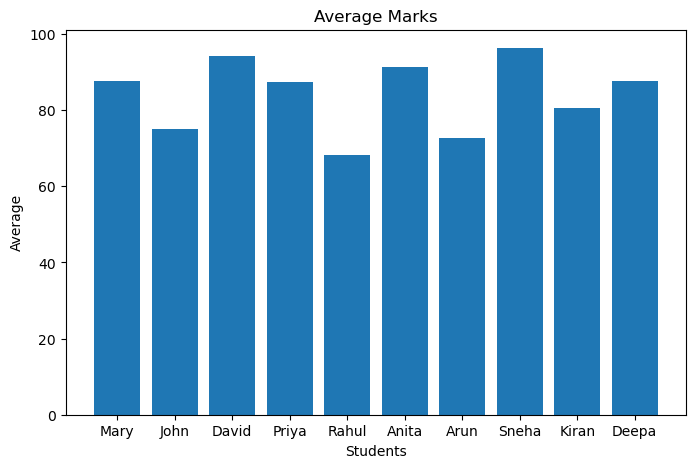

In [83]:
# Visualize the average marks of each student
plt.figure(figsize=(8,5))

plt.bar(df["Name"], df["Average"])

plt.title("Average Marks")

plt.xlabel("Students")

plt.ylabel("Average")

plt.show()

### Observation

The bar chart compares the average marks of all students.

It helps identify the highest and lowest performing students quickly.

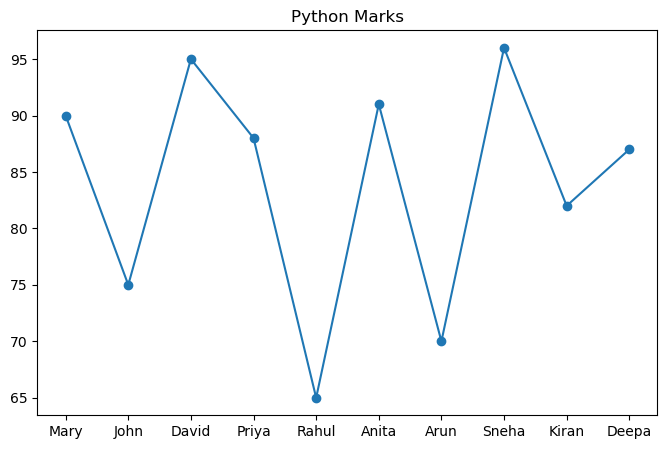

In [84]:
# Display Python marks using a line chart
plt.figure(figsize=(8,5))

plt.plot(df["Name"], df["Python"], marker="o")

plt.title("Python Marks")

plt.show()

### Observation

The line chart illustrates the variation in Python marks among students.

It clearly shows performance trends.

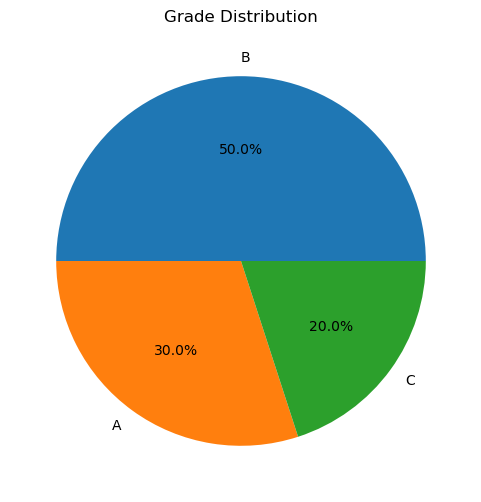

In [85]:
# Display the distribution of grades
grade_counts = df["Grade"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    grade_counts,
    labels=grade_counts.index,
    autopct="%1.1f%%"
)

plt.title("Grade Distribution")

plt.show()

### Observation

The pie chart displays the percentage distribution of student grades.

This provides a quick overview of overall academic performance.

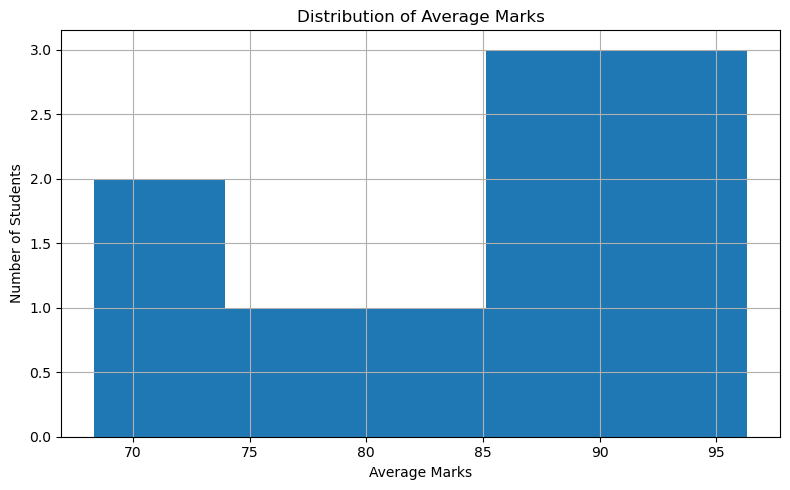

In [86]:
# Display the distribution of average marks
plt.figure(figsize=(8,5))

plt.hist(df["Average"], bins=5)

plt.title("Distribution of Average Marks")

plt.xlabel("Average Marks")

plt.ylabel("Number of Students")

plt.grid(True)

plt.tight_layout()

plt.show()

### Observation

The histogram shows the distribution of students based on their average marks. Most students scored within the higher average range, indicating generally good academic performance.

In [87]:
# Display the correlation between numerical features
print(df[["Python", "SQL", "PowerBI", "Average"]].corr())

           Python       SQL   PowerBI   Average
Python   1.000000  0.926977  0.969327  0.991512
SQL      0.926977  1.000000  0.886400  0.954304
PowerBI  0.969327  0.886400  1.000000  0.979990
Average  0.991512  0.954304  0.979990  1.000000


In [88]:
# Create a summary table of key performance metrics
summary = pd.DataFrame({
    "Metric": [
        "Total Students",
        "Average Python Marks",
        "Highest Average",
        "Lowest Average"
    ],
    "Value": [
        len(df),
        df["Python"].mean(),
        df["Average"].max(),
        df["Average"].min()
    ]
})

summary

,Metric,Value
0,Total Students,10.000000
1,Average Python Marks,83.900000
2,Highest Average,96.333333
3,Lowest Average,68.333333


## 8. Export Processed Dataset

Save the processed dataset to a new CSV file for future use.

In [89]:
# Save the processed dataset to a new CSV file
df.to_csv(
    "../data/cleaned_students.csv",
    index=False
)

## Key Insights

- The highest average score was achieved by the top-performing student.
- Students were successfully categorized into grades based on their average marks.
- Visualizations made it easier to compare performance across students.
- The processed dataset was exported successfully for future analysis.

# 9. Conclusion

## Project Summary

This project successfully demonstrates the use of Python, NumPy, Pandas, and Matplotlib for basic data analysis.

### Key Achievements

- Successfully loaded a CSV dataset
- Explored and summarized the dataset
- Created new calculated columns
- Assigned grades based on average marks
- Visualized student performance
- Exported the processed dataset

### Skills Demonstrated

- Python Programming
- NumPy
- Pandas
- Data Cleaning
- Feature Engineering
- Data Visualization
- CSV File Handling